# Consensus-Label Hawk/Dove — Intraday Backtest (bps)

**No NLP. No trailing averages.** Each speaker gets a single static hawk/dove label
based on market consensus (BBG, sellside notes, financial twitter).
Tests whether just knowing "Bowman is a hawk, Goolsbee is a dove" is enough signal.

Same flat sizing, same entry/exit offsets, same contract as the NLP-based notebooks.
Comparison overlay with `trailing_5_avg` at the end.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, r"C:\Users\chris\clee\ARBS")

import datetime
import pytz
import re
import numpy as np
import pandas as pd
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
plt.style.use("ggplot")
params = {
    "legend.fontsize": "large",
    "figure.figsize": (14, 8),
    "axes.labelsize": "x-large",
    "axes.titlesize": "x-large",
    "xtick.labelsize": "large",
    "ytick.labelsize": "large",
}
pylab.rcParams.update(params)

import QuantLib as ql

NYC_tz = pytz.timezone("America/New_York")

ENTRY_OFFSET = datetime.timedelta(minutes=45)
EXIT_OFFSET = datetime.timedelta(minutes=180)
CURVE = "USD-SOFR-1D-Q12STIRT"
TENOR = "IMM_3xIMM_4"
BASE_BPV = 100_000
EARLIEST_SPEECH = datetime.time(7, 0)
LATEST_SPEECH = datetime.time(17, 0)
BLACKOUT_BD = 1
MDP_SOURCE = "BARCHART_STIRF-RL"
BT_START = "2021-01-01"
BT_END = "2026-06-24"

# =====================================================================
# STATIC CONSENSUS LABELS
# +1 = hawk (pay fixed / short SFR around their speeches)
# -1 = dove (receive fixed / long SFR around their speeches)
#  0 = neutral / skip
#
# Source: market consensus from BBG, sellside, fin-twitter.
# These are STATIC for the full sample — no time variation.
# =====================================================================
CONSENSUS = {
    # --- Hawks ---
    "Bowman":   +1,  # hardline hawk — dissented vs 50bp cut Sep 2024
    "George":   +1,  # traditional KC Fed hawk (retired 2023)
    "Logan":    +1,  # Dallas Fed hawk
    "Mester":   +1,  # Cleveland Fed hawk (retired 2024)
    "Schmid":   +1,  # KC Fed — hawkish successor
    "Hammack":  +1,  # Cleveland Fed — hawkish successor
    "Musalem":  +1,  # St Louis Fed — hawkish
    "Warsh":    +1,  # Fed Chair from 2026 — "price stability" hawk
    "Barkin":   +1,  # Richmond Fed — lean hawk
    "Kashkari": +1,  # Minneapolis — hawk in 2022-2026 era (called for higher terminal)

    # --- Doves ---
    "Brainard": -1,  # strong dove (left for NEC 2023)
    "Bostic":   -1,  # Atlanta Fed dove
    "Goolsbee": -1,  # Chicago Fed dove
    "Cook":     -1,  # Board governor — dove
    "Daly":     -1,  # SF Fed dove
    "Kugler":   -1,  # Board governor — dove
    "Harker":   -1,  # Philly Fed — leaned dovish, voted for pauses

    # --- Neutral / Skip ---
    "Powell":    0,  # chair — reflects committee consensus, not personal lean
    "Williams":  0,  # NY Fed — centrist by design
    "Jefferson": 0,  # Vice Chair — centrist
    "Collins":   0,  # Boston Fed — moderate, hard to bucket
    "Waller":    0,  # shifted from hawk (2021-23) to dove (2024+) — static label unreliable
    "Barr":      0,  # Vice Chair supervision — rarely speaks on rates policy
}

print("Consensus labels:")
for label_val, label_name in [(+1, "HAWK"), (-1, "DOVE"), (0, "NEUTRAL")]:
    names = [k for k, v in CONSENSUS.items() if v == label_val]
    print(f"  {label_name:8s} ({len(names):2d}): {', '.join(sorted(names))}")

Consensus labels:
  HAWK     (10): Barkin, Bowman, George, Hammack, Kashkari, Logan, Mester, Musalem, Schmid, Warsh
  DOVE     ( 7): Bostic, Brainard, Cook, Daly, Goolsbee, Harker, Kugler
  NEUTRAL  ( 6): Barr, Collins, Jefferson, Powell, Waller, Williams


## 1. Load ForexFactory Events

In [2]:
from RVUtils.forex_factory_calendar import ForexFactoryCalendarFetcher, ForexFactoryTheme

fetcher = ForexFactoryCalendarFetcher()
fed_speak_df = fetcher.fetch_range(
    BT_START, BT_END,
    themes=[ForexFactoryTheme.FED_SPEAKERS],
    show_tqdm=True, bulk_chunk_weeks=52,
)
print(f"ForexFactory events: {len(fed_speak_df)}")

Fetching missing Forex Factory weeks: 0it [00:00, ?it/s]

Fetching missing Forex Factory weeks: 0it [00:00, ?it/s]

ForexFactory events: 1477


## 2. Build Trade Events (Static Labels)

In [3]:
FOMC_DATES = [
    datetime.date(2020, 1, 29), datetime.date(2020, 3, 15), datetime.date(2020, 4, 29),
    datetime.date(2020, 6, 10), datetime.date(2020, 7, 29), datetime.date(2020, 9, 16),
    datetime.date(2020, 11, 5), datetime.date(2020, 12, 16),
    datetime.date(2021, 1, 27), datetime.date(2021, 3, 17), datetime.date(2021, 4, 28),
    datetime.date(2021, 6, 16), datetime.date(2021, 7, 28), datetime.date(2021, 9, 22),
    datetime.date(2021, 11, 3), datetime.date(2021, 12, 15),
    datetime.date(2022, 1, 26), datetime.date(2022, 3, 16), datetime.date(2022, 5, 4),
    datetime.date(2022, 6, 15), datetime.date(2022, 7, 27), datetime.date(2022, 9, 21),
    datetime.date(2022, 11, 2), datetime.date(2022, 12, 14),
    datetime.date(2023, 2, 1), datetime.date(2023, 3, 22), datetime.date(2023, 5, 3),
    datetime.date(2023, 6, 14), datetime.date(2023, 7, 26), datetime.date(2023, 9, 20),
    datetime.date(2023, 11, 1), datetime.date(2023, 12, 13),
    datetime.date(2024, 1, 31), datetime.date(2024, 3, 20), datetime.date(2024, 5, 1),
    datetime.date(2024, 6, 12), datetime.date(2024, 7, 31), datetime.date(2024, 9, 18),
    datetime.date(2024, 11, 7), datetime.date(2024, 12, 18),
    datetime.date(2025, 1, 29), datetime.date(2025, 3, 19), datetime.date(2025, 5, 7),
    datetime.date(2025, 6, 18), datetime.date(2025, 7, 30), datetime.date(2025, 9, 17),
    datetime.date(2025, 10, 29), datetime.date(2025, 12, 10),
    datetime.date(2026, 1, 28), datetime.date(2026, 3, 18), datetime.date(2026, 4, 29),
    datetime.date(2026, 6, 17),
]
ql_cal = ql.UnitedStates(ql.UnitedStates.GovernmentBond)


def extract_speaker(title):
    cleaned = re.sub(r"\b(Speaks?|Testifies|Testimony)\b", "", title).strip()
    return cleaned.split()[-1] if cleaned.split() else ""


def is_in_blackout(event_date):
    for fomc in FOMC_DATES:
        s = ql.Date(fomc.day, fomc.month, fomc.year)
        lo = ql_cal.advance(s, ql.Period(-BLACKOUT_BD, ql.Days), ql.Preceding)
        hi = ql_cal.advance(s, ql.Period(BLACKOUT_BD, ql.Days), ql.Following)
        if (datetime.date(lo.year(), lo.month(), lo.dayOfMonth())
                <= event_date
                <= datetime.date(hi.year(), hi.month(), hi.dayOfMonth())):
            return True
    return False


def cap_exit(exit_ts, entry_ts):
    exit_ql = ql.Date(exit_ts.day, exit_ts.month, exit_ts.year)
    if exit_ts.hour >= 17:
        return exit_ts.replace(hour=16, minute=59, second=0, microsecond=0)
    if not ql_cal.isBusinessDay(exit_ql):
        return entry_ts.replace(hour=16, minute=59, second=0, microsecond=0)
    return exit_ts


trade_events = []
excluded = defaultdict(int)

for _, row in fed_speak_df.iterrows():
    speaker = extract_speaker(row["Title"])
    if speaker not in CONSENSUS:
        excluded["unknown_speaker"] += 1
        continue
    direction = CONSENSUS[speaker]
    if direction == 0:
        excluded["neutral_label"] += 1
        continue
    ts = row["TimestampNYC"]
    if pd.isna(ts):
        excluded["no_timestamp"] += 1
        continue
    if ts.tzinfo is None:
        ts = NYC_tz.localize(ts)
    if ts.time() < EARLIEST_SPEECH or ts.time() > LATEST_SPEECH:
        excluded["outside_hours"] += 1
        continue
    if is_in_blackout(ts.date()):
        excluded["blackout"] += 1
        continue
    if "press conference" in row["Title"].lower():
        excluded["presser"] += 1
        continue
    entry = ts - ENTRY_OFFSET
    exit_ = ts + EXIT_OFFSET
    entry_ql = ql.Date(entry.day, entry.month, entry.year)
    if not ql_cal.isBusinessDay(entry_ql):
        excluded["entry_not_bday"] += 1
        continue
    exit_ = cap_exit(exit_, entry)
    trade_events.append({
        "speaker": speaker, "speech_ts": ts,
        "entry_ts": entry, "exit_ts": exit_,
        "direction": direction,
        "direction_label": "hawk" if direction == 1 else "dove",
        "bpv": -direction * BASE_BPV,
        "tag": f"s_{len(trade_events)}",
    })

# No-stacking filter
trade_events.sort(key=lambda e: e["entry_ts"])
filtered, last_exit = [], None
overlap_n = 0
for ev in trade_events:
    if last_exit is not None and ev["entry_ts"] < last_exit:
        overlap_n += 1
        continue
    filtered.append(ev)
    last_exit = ev["exit_ts"]
trade_events = filtered

print(f"--- Event Filtering ---")
print(f"Total events: {len(fed_speak_df)}")
for reason, count in sorted(excluded.items(), key=lambda x: -x[1]):
    print(f"  Excluded ({reason}): {count}")
print(f"  Removed for overlap: {overlap_n}")
print(f"  Final trades: {len(trade_events)}")

edf = pd.DataFrame(trade_events)
n_h = (edf.direction == 1).sum()
n_d = (edf.direction == -1).sum()
print(f"\n  Hawk: {n_h}, Dove: {n_d}")

--- Event Filtering ---
Total events: 1477
  Excluded (neutral_label): 502
  Excluded (unknown_speaker): 115
  Excluded (outside_hours): 110
  Excluded (entry_not_bday): 16
  Excluded (blackout): 5
  Removed for overlap: 206
  Final trades: 523

  Hawk: 258, Dove: 265


## 3. Run Backtest

In [4]:
from BT.data_handler import TimeGrid
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import Trigger, FlowSignalTriggerRequirements
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue

curve_mdp = IRSwapsMDP(source=MDP_SOURCE)

exit_set = set(e["exit_ts"] for e in trade_events)
ts_all = sorted(set(e["entry_ts"] for e in trade_events) | exit_set)

exit_trig = Trigger(
    trigger_requirements=FlowSignalTriggerRequirements(
        signal_fn=lambda s, bt: s in exit_set),
    actions=[UnwindPositionsAction(match_all=True, fee=0.0)])

entry_trigs = []
for ev in trade_events:
    _ts = ev["entry_ts"]
    _q = IRSwapQuery(
        curve=CURVE, tenor=TENOR, value=IRSwapValue.NPV,
        structure_kwargs={"bpv": ev["bpv"]}, tags=(ev["tag"],),
        meta={"speaker": ev["speaker"], "direction": ev["direction"]})

    def _mk(t):
        def fn(s, bt): return s == t and len(bt.portfolio.positions) == 0
        return fn

    entry_trigs.append(Trigger(
        trigger_requirements=FlowSignalTriggerRequirements(signal_fn=_mk(_ts)),
        actions=[AddQueryAction(query=_q)]))

strategy = QueryStrategy(name="Consensus Labels", triggers=[exit_trig] + entry_trigs)
bt = QueryDrivenBacktest(
    time_grid=TimeGrid(ts_all), mdp=curve_mdp, strategy=strategy,
    show_progress=True, progress_desc="Consensus BT")
bt.run()
print(f"\nTrades executed: {len(bt.portfolio.trades_log)}")

Consensus BT:   0%|          | 0/1040 [00:00<?, ?step/s]

Consensus BT:   0%|          | 1/1040 [00:00<09:30,  1.82step/s]

Consensus BT:   0%|          | 5/1040 [00:00<01:57,  8.82step/s]

Consensus BT:   1%|          | 9/1040 [00:04<08:56,  1.92step/s]

Consensus BT:   1%|▏         | 13/1040 [00:04<05:14,  3.27step/s]

...

Consensus BT:  99%|█████████▉| 1030/1040 [02:07<00:00, 23.75step/s]

Consensus BT:  99%|█████████▉| 1033/1040 [02:07<00:00, 22.69step/s]

Consensus BT: 100%|█████████▉| 1037/1040 [02:08<00:00, 24.13step/s]

Consensus BT: 100%|██████████| 1040/1040 [02:08<00:00,  8.11step/s]


Trades executed: 517


## 4. Core Metrics & Cumulative P&L (bps)

  Consensus-Label Hawk/Dove — IMM_3xIMM_4
  Entry: T-0:45:00, Exit: T+3:00:00
  Trades:          516
  Cumulative:      +124.0 bps
  Avg P&L/trade:   +0.240 bps
  Median P&L:      +0.000 bps
  Std P&L:         3.53 bps
  Hit Rate:        52.9%
  Skew:            +2.31
  Kurtosis:        16.6
  Sharpe:          0.67
  Max Drawdown:    -48.2 bps


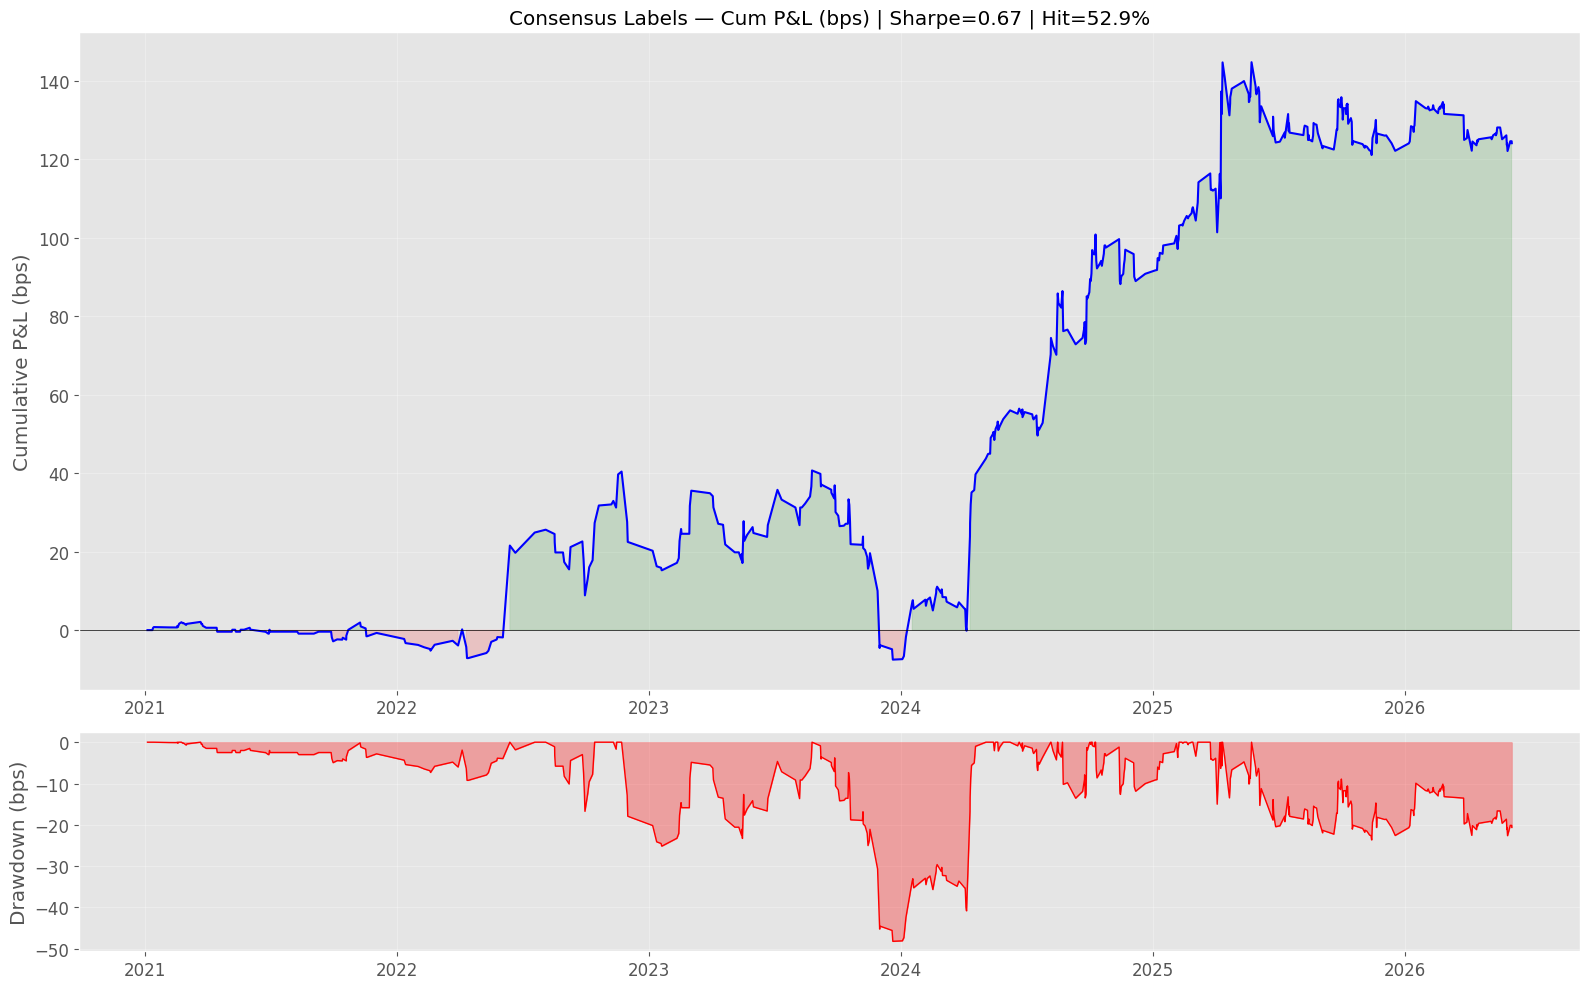

In [5]:
closed = pd.DataFrame(bt.portfolio.closed_positions_log)
assert not closed.empty

closed["speaker"] = closed["source_query"].apply(lambda q: q.meta["speaker"])
closed["direction"] = closed["source_query"].apply(lambda q: q.meta["direction"])
closed["direction_label"] = closed["direction"].apply(lambda d: "hawk" if d == 1 else "dove")
closed["opened_at"] = pd.to_datetime(closed["opened_at"])
closed["closed_at"] = pd.to_datetime(closed["closed_at"])
closed["year"] = closed["opened_at"].dt.year
closed["pnl_bps"] = closed["realized_pnl"] / BASE_BPV
closed["profitable"] = closed["pnl_bps"] > 0
closed["cum_bps"] = closed["pnl_bps"].cumsum()

n = len(closed)
cum = closed["pnl_bps"].sum()
avg = closed["pnl_bps"].mean()
med = closed["pnl_bps"].median()
std = closed["pnl_bps"].std()
hit = closed["profitable"].mean()
skw = closed["pnl_bps"].skew()
kurt = closed["pnl_bps"].kurtosis()
yrs = max((closed["opened_at"].max() - closed["opened_at"].min()).days / 365.25, 0.5)
tpy = n / yrs
sr = (avg / std * np.sqrt(tpy)) if std > 0 else 0
dd = (closed["cum_bps"] - closed["cum_bps"].cummax()).min()

print("=" * 55)
print(f"  Consensus-Label Hawk/Dove — {TENOR}")
print(f"  Entry: T-{ENTRY_OFFSET}, Exit: T+{EXIT_OFFSET}")
print("=" * 55)
print(f"  Trades:          {n}")
print(f"  Cumulative:      {cum:+.1f} bps")
print(f"  Avg P&L/trade:   {avg:+.3f} bps")
print(f"  Median P&L:      {med:+.3f} bps")
print(f"  Std P&L:         {std:.2f} bps")
print(f"  Hit Rate:        {hit:.1%}")
print(f"  Skew:            {skw:+.2f}")
print(f"  Kurtosis:        {kurt:.1f}")
print(f"  Sharpe:          {sr:.2f}")
print(f"  Max Drawdown:    {dd:.1f} bps")
print("=" * 55)

fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={"height_ratios": [3, 1]})
ax = axes[0]
ax.plot(closed["opened_at"].values, closed["cum_bps"].values, "b-", lw=1.5)
ax.fill_between(closed["opened_at"].values, 0, closed["cum_bps"].values,
                where=closed["cum_bps"].values >= 0, alpha=0.15, color="green")
ax.fill_between(closed["opened_at"].values, 0, closed["cum_bps"].values,
                where=closed["cum_bps"].values < 0, alpha=0.15, color="red")
ax.axhline(0, color="k", lw=0.5)
ax.set_title(f"Consensus Labels — Cum P&L (bps) | Sharpe={sr:.2f} | Hit={hit:.1%}")
ax.set_ylabel("Cumulative P&L (bps)")
ax.grid(True, alpha=0.3)

ax2 = axes[1]
dd_series = closed["cum_bps"] - closed["cum_bps"].cummax()
ax2.fill_between(closed["opened_at"].values, dd_series.values, 0, alpha=0.3, color="red")
ax2.plot(closed["opened_at"].values, dd_series.values, "r-", lw=1)
ax2.set_ylabel("Drawdown (bps)")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. P&L Distribution

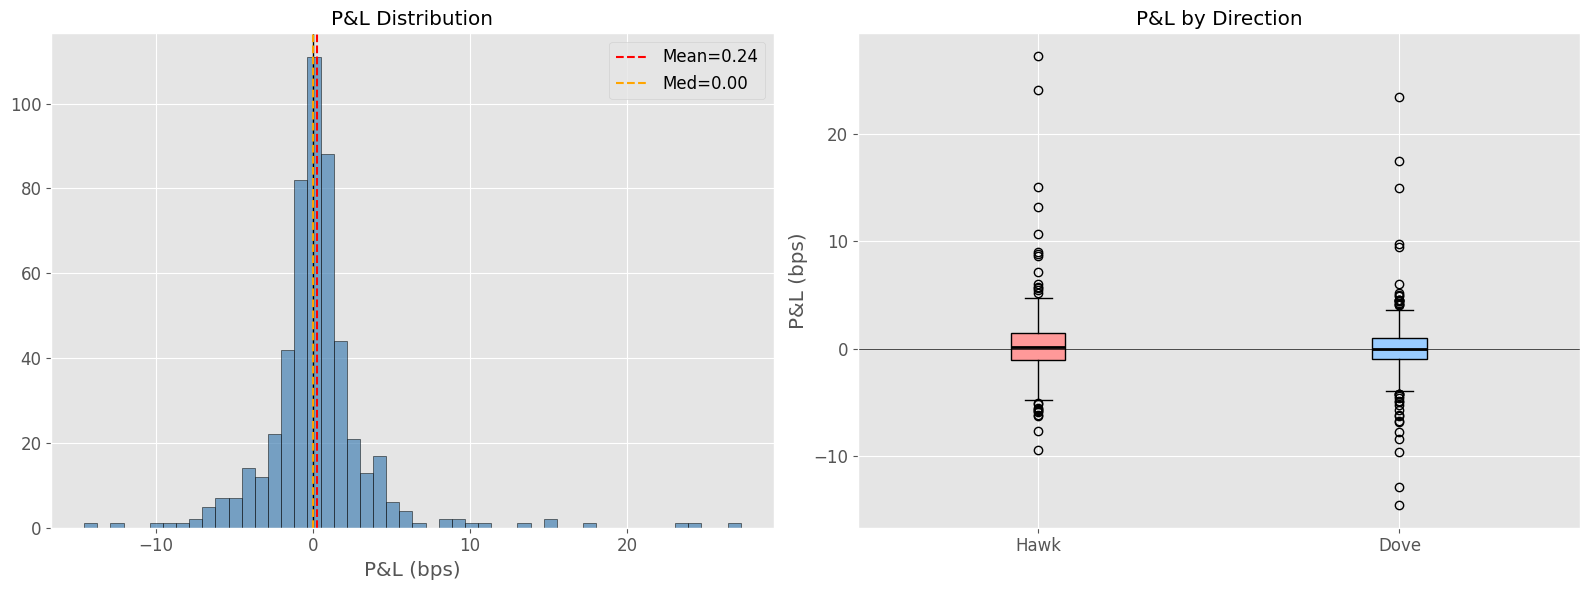

Percentiles:


,Pct,bps
0,1%,-7.70
1,5%,-4.53
2,10%,-2.85
3,25%,-1.00
4,50%,0.00
5,75%,1.19
6,90%,3.01
7,95%,4.49
8,99%,14.64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.hist(closed["pnl_bps"], bins=50, alpha=0.7, color="steelblue", edgecolor="black")
ax.axvline(0, color="k", lw=1)
ax.axvline(avg, color="red", ls="--", lw=1.5, label=f"Mean={avg:.2f}")
ax.axvline(med, color="orange", ls="--", lw=1.5, label=f"Med={med:.2f}")
ax.set_xlabel("P&L (bps)")
ax.set_title("P&L Distribution")
ax.legend()

ax2 = axes[1]
hawk_bps = closed.loc[closed["direction"] == 1, "pnl_bps"]
dove_bps = closed.loc[closed["direction"] == -1, "pnl_bps"]
bp = ax2.boxplot([hawk_bps, dove_bps], tick_labels=["Hawk", "Dove"], patch_artist=True,
                 medianprops={"color": "black", "lw": 2})
bp["boxes"][0].set_facecolor("#ff9999")
bp["boxes"][1].set_facecolor("#99ccff")
ax2.axhline(0, color="k", lw=0.5)
ax2.set_ylabel("P&L (bps)")
ax2.set_title("P&L by Direction")
plt.tight_layout()
plt.show()

pcts = [1, 5, 10, 25, 50, 75, 90, 95, 99]
pct_df = pd.DataFrame({"Pct": [f"{p}%" for p in pcts],
                        "bps": np.percentile(closed["pnl_bps"], pcts)})
print("Percentiles:")
display(pct_df.style.format({"bps": "{:.2f}"}))

## 6. Calendar-Year Breakdown

,trades,total_bps,avg_bps,med_bps,std_bps,hit_rate,sharpe
year,,,,,,,
2021,74,-0.7,-0.010,+0.000,0.54,51.4%,-0.16
2022,49,+23.2,+0.473,+0.016,4.84,53.1%,0.68
2023,74,-30.0,-0.405,-0.635,3.65,41.9%,-0.96
2024,119,+98.3,+0.826,+0.636,4.04,59.7%,2.23
2025,144,+31.3,+0.218,+0.077,3.85,52.1%,0.68
2026,56,+1.9,+0.035,+0.269,1.76,57.1%,0.15


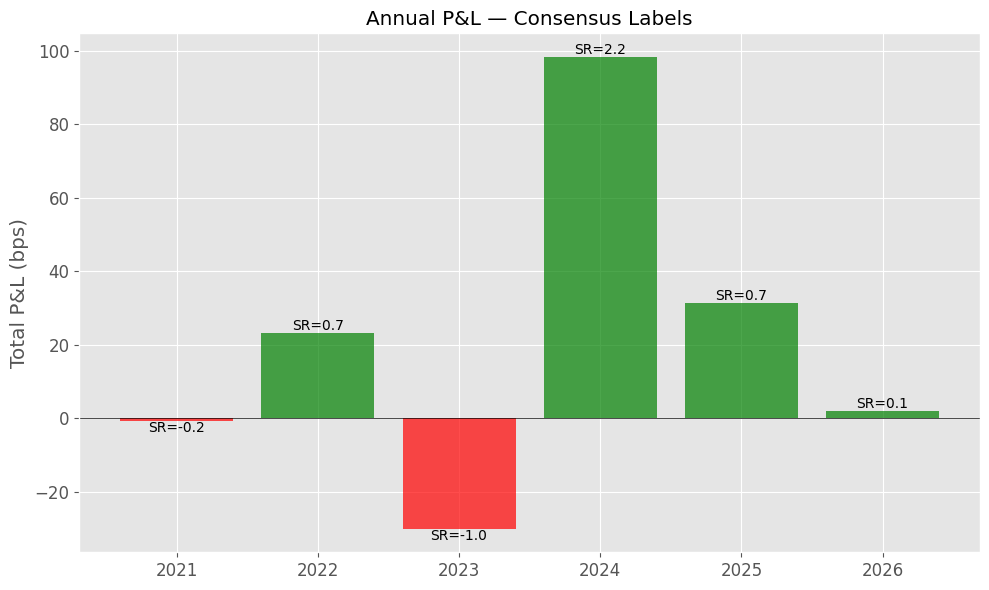

In [7]:
year_stats = (
    closed.groupby("year")
    .agg(trades=("pnl_bps", "count"), total_bps=("pnl_bps", "sum"),
         avg_bps=("pnl_bps", "mean"), med_bps=("pnl_bps", "median"),
         std_bps=("pnl_bps", "std"), hit_rate=("profitable", "mean"))
)
year_stats["sharpe"] = (year_stats["avg_bps"] / year_stats["std_bps"]) * np.sqrt(year_stats["trades"])

display(year_stats.style.format({
    "total_bps": "{:+.1f}", "avg_bps": "{:+.3f}", "med_bps": "{:+.3f}",
    "std_bps": "{:.2f}", "hit_rate": "{:.1%}", "sharpe": "{:.2f}",
}))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["green" if x > 0 else "red" for x in year_stats["total_bps"]]
ax.bar(year_stats.index.astype(str), year_stats["total_bps"], color=colors, alpha=0.7)
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Total P&L (bps)")
ax.set_title("Annual P&L — Consensus Labels")
for i, (yr, row) in enumerate(year_stats.iterrows()):
    ax.text(i, row["total_bps"], f"SR={row['sharpe']:.1f}", ha="center",
            va="bottom" if row["total_bps"] >= 0 else "top", fontsize=10)
plt.tight_layout()
plt.show()

## 7. Hawk vs Dove

,trades,total_bps,avg_bps,med_bps,std_bps,hit_rate
direction_label,,,,,,
hawk,253,+109.7,+0.434,+0.124,3.70,54.5%
dove,263,+14.3,+0.054,+0.000,3.36,51.3%


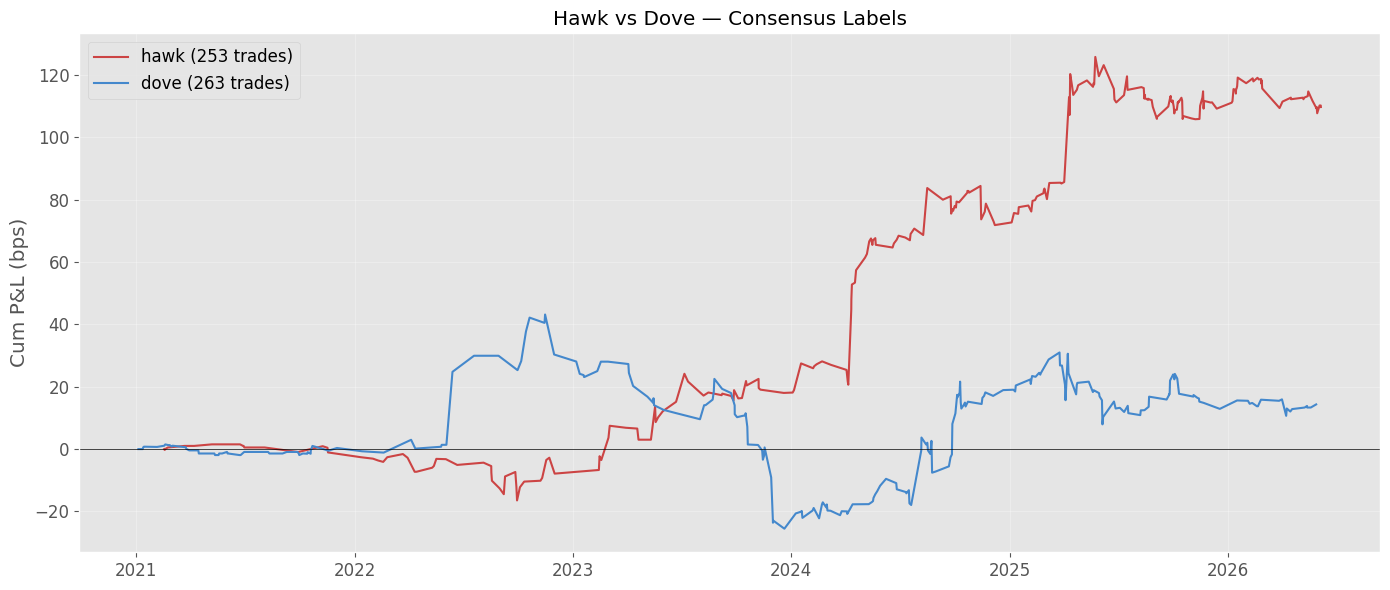

In [8]:
dir_stats = (
    closed.groupby("direction_label")
    .agg(trades=("pnl_bps", "count"), total_bps=("pnl_bps", "sum"),
         avg_bps=("pnl_bps", "mean"), med_bps=("pnl_bps", "median"),
         std_bps=("pnl_bps", "std"), hit_rate=("profitable", "mean"))
    .sort_values("total_bps", ascending=False)
)
display(dir_stats.style.format({
    "total_bps": "{:+.1f}", "avg_bps": "{:+.3f}", "med_bps": "{:+.3f}",
    "std_bps": "{:.2f}", "hit_rate": "{:.1%}",
}))

fig, ax = plt.subplots(figsize=(14, 6))
for label, color in [("hawk", "#cc4444"), ("dove", "#4488cc")]:
    mask = closed["direction_label"] == label
    sub = closed[mask].sort_values("opened_at")
    ax.plot(sub["opened_at"].values, sub["pnl_bps"].cumsum().values,
            lw=1.5, color=color, label=f"{label} ({mask.sum()} trades)")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Cum P&L (bps)")
ax.set_title("Hawk vs Dove — Consensus Labels")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Speaker Attribution

,trades,total_bps,avg_bps,hit_rate
speaker,,,,
Musalem,23,+32.3,+1.403,60.9%
Logan,23,+28.9,+1.255,60.9%
Brainard,25,+23.9,+0.954,56.0%
Bowman,72,+18.8,+0.261,47.2%
Kugler,17,+14.7,+0.866,52.9%
Barkin,60,+14.4,+0.240,53.3%
Harker,22,+13.6,+0.618,63.6%
Kashkari,21,+12.4,+0.593,81.0%
Bostic,84,+9.4,+0.112,53.6%


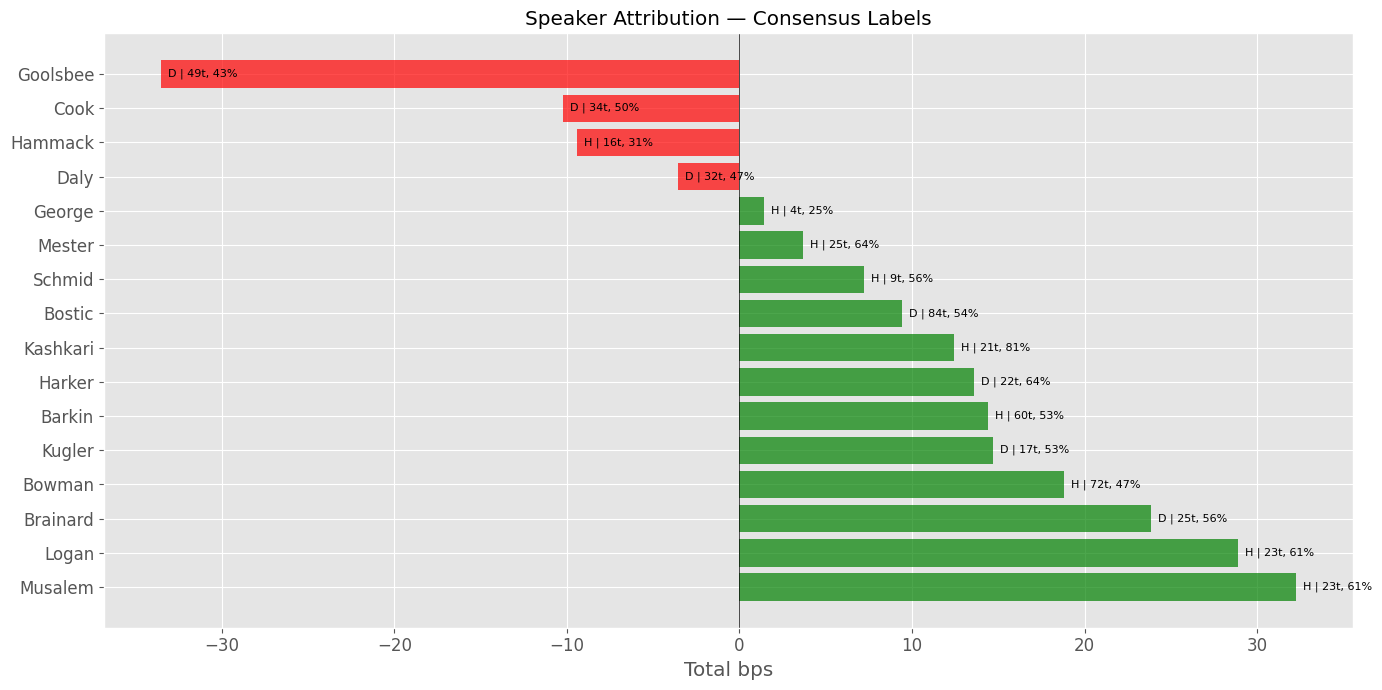

In [9]:
sp = closed.groupby("speaker").agg(
    trades=("pnl_bps", "count"), total_bps=("pnl_bps", "sum"),
    avg_bps=("pnl_bps", "mean"), hit_rate=("profitable", "mean"),
).sort_values("total_bps", ascending=False)

display(sp.style.format({
    "total_bps": "{:+.1f}", "avg_bps": "{:+.3f}", "hit_rate": "{:.1%}",
}))

fig, ax = plt.subplots(figsize=(14, 7))
colors = ["green" if x > 0 else "red" for x in sp["total_bps"]]
ax.barh(sp.index, sp["total_bps"], color=colors, alpha=0.7)
ax.axvline(0, color="k", lw=0.5)
ax.set_xlabel("Total bps")
ax.set_title("Speaker Attribution — Consensus Labels")
for i, (speaker, row) in enumerate(sp.iterrows()):
    label = CONSENSUS.get(speaker, 0)
    tag = "H" if label == 1 else "D"
    ax.text(row["total_bps"], i,
            f"  {tag} | {row['trades']:.0f}t, {row['hit_rate']:.0%}",
            va="center", fontsize=8)
plt.tight_layout()
plt.show()

## 9. Comparison: Consensus vs NLP Metrics

In [10]:
# Run trailing_5_avg backtest for overlay comparison
jpm_scores = pd.read_csv(
    r"C:\Users\chris\clee\project-oasis\private\jpm_research\fed_speak_nlp\fed_hawk_dove_scores.csv"
)
jpm_scores["date"] = pd.to_datetime(jpm_scores["date"]).dt.date
jpm_scores = jpm_scores.sort_values(["speaker", "date"]).reset_index(drop=True)
KNOWN_SPEAKERS = sorted(jpm_scores["speaker"].unique())

NLP_METRICS = ["trailing_5_avg", "cb_3m_trailing_avg"]
HAWK_THRESHOLD, DOVE_THRESHOLD = 10, -10

def build_nlp_cache(metric):
    cache = {}
    for speaker, grp in jpm_scores.groupby("speaker"):
        g = grp.sort_values("date")
        cache[speaker] = (g["date"].values, g[metric].values)
    return cache

def get_nlp_score(cache, speaker, as_of):
    if speaker not in cache:
        return np.nan
    dates, scores = cache[speaker]
    mask = dates < np.datetime64(as_of)
    return float(scores[mask][-1]) if mask.any() else np.nan

def build_nlp_events(metric):
    cache = build_nlp_cache(metric)
    events = []
    for _, row in fed_speak_df.iterrows():
        speaker = extract_speaker(row["Title"])
        if speaker not in KNOWN_SPEAKERS:
            continue
        ts = row["TimestampNYC"]
        if pd.isna(ts):
            continue
        if ts.tzinfo is None:
            ts = NYC_tz.localize(ts)
        if ts.time() < EARLIEST_SPEECH or ts.time() > LATEST_SPEECH:
            continue
        if is_in_blackout(ts.date()):
            continue
        if "press conference" in row["Title"].lower():
            continue
        raw = get_nlp_score(cache, speaker, ts.date())
        if pd.isna(raw):
            continue
        d = 1 if raw >= HAWK_THRESHOLD else (-1 if raw <= DOVE_THRESHOLD else 0)
        if d == 0:
            continue
        entry = ts - ENTRY_OFFSET
        exit_ = ts + EXIT_OFFSET
        entry_ql = ql.Date(entry.day, entry.month, entry.year)
        if not ql_cal.isBusinessDay(entry_ql):
            continue
        exit_ = cap_exit(exit_, entry)
        events.append({
            "speaker": speaker, "speech_ts": ts,
            "entry_ts": entry, "exit_ts": exit_,
            "direction": d, "bpv": -d * BASE_BPV,
            "tag": f"n_{len(events)}",
            "raw_score": raw,
        })
    events.sort(key=lambda e: e["entry_ts"])
    filt, last = [], None
    for ev in events:
        if last is not None and ev["entry_ts"] < last:
            continue
        filt.append(ev)
        last = ev["exit_ts"]
    return filt

def run_nlp_bt(events):
    exit_set = set(e["exit_ts"] for e in events)
    ts_all = sorted(set(e["entry_ts"] for e in events) | exit_set)
    exit_trig = Trigger(
        trigger_requirements=FlowSignalTriggerRequirements(
            signal_fn=lambda s, bt: s in exit_set),
        actions=[UnwindPositionsAction(match_all=True, fee=0.0)])
    entry_trigs = []
    for ev in events:
        _ts = ev["entry_ts"]
        _q = IRSwapQuery(
            curve=CURVE, tenor=TENOR, value=IRSwapValue.NPV,
            structure_kwargs={"bpv": ev["bpv"]}, tags=(ev["tag"],),
            meta={"speaker": ev["speaker"], "direction": ev["direction"],
                  "raw_score": ev["raw_score"]})
        def _mk(t):
            def fn(s, bt): return s == t and len(bt.portfolio.positions) == 0
            return fn
        entry_trigs.append(Trigger(
            trigger_requirements=FlowSignalTriggerRequirements(signal_fn=_mk(_ts)),
            actions=[AddQueryAction(query=_q)]))
    strat = QueryStrategy(name="nlp", triggers=[exit_trig] + entry_trigs)
    bt2 = QueryDrivenBacktest(time_grid=TimeGrid(ts_all), mdp=curve_mdp, strategy=strat,
                              show_progress=True, progress_desc="  NLP BT")
    bt2.run()
    cl = pd.DataFrame(bt2.portfolio.closed_positions_log)
    cl["speaker"] = cl["source_query"].apply(lambda q: q.meta["speaker"])
    cl["direction"] = cl["source_query"].apply(lambda q: q.meta["direction"])
    cl["direction_label"] = cl["direction"].apply(lambda d: "hawk" if d == 1 else "dove")
    cl["opened_at"] = pd.to_datetime(cl["opened_at"])
    cl["year"] = cl["opened_at"].dt.year
    cl["pnl_bps"] = cl["realized_pnl"] / BASE_BPV
    cl["profitable"] = cl["pnl_bps"] > 0
    cl["cum_bps"] = cl["pnl_bps"].cumsum()
    return cl

nlp_closed = {}
for metric in NLP_METRICS:
    print(f"Running {metric}...")
    evts = build_nlp_events(metric)
    nlp_closed[metric] = run_nlp_bt(evts)
    print(f"  {len(nlp_closed[metric])} trades, {nlp_closed[metric]['pnl_bps'].sum():+.1f} bps")

print("Done.")

Running trailing_5_avg...


  NLP BT:   0%|          | 0/914 [00:00<?, ?step/s]

  NLP BT:   0%|          | 3/914 [00:00<00:35, 25.31step/s]

  NLP BT:   1%|          | 7/914 [00:00<00:33, 27.20step/s]

  NLP BT:   1%|          | 11/914 [00:00<00:32, 28.18step/s]

...

  NLP BT:  99%|█████████▊| 658/667 [00:24<00:00, 28.14step/s]

  NLP BT:  99%|█████████▉| 662/667 [00:24<00:00, 28.23step/s]

  NLP BT: 100%|█████████▉| 666/667 [00:24<00:00, 28.24step/s]

  NLP BT: 100%|██████████| 667/667 [00:24<00:00, 27.11step/s]

  333 trades, +168.0 bps
Done.


## 10. Equity Curve Overlay — Consensus vs NLP

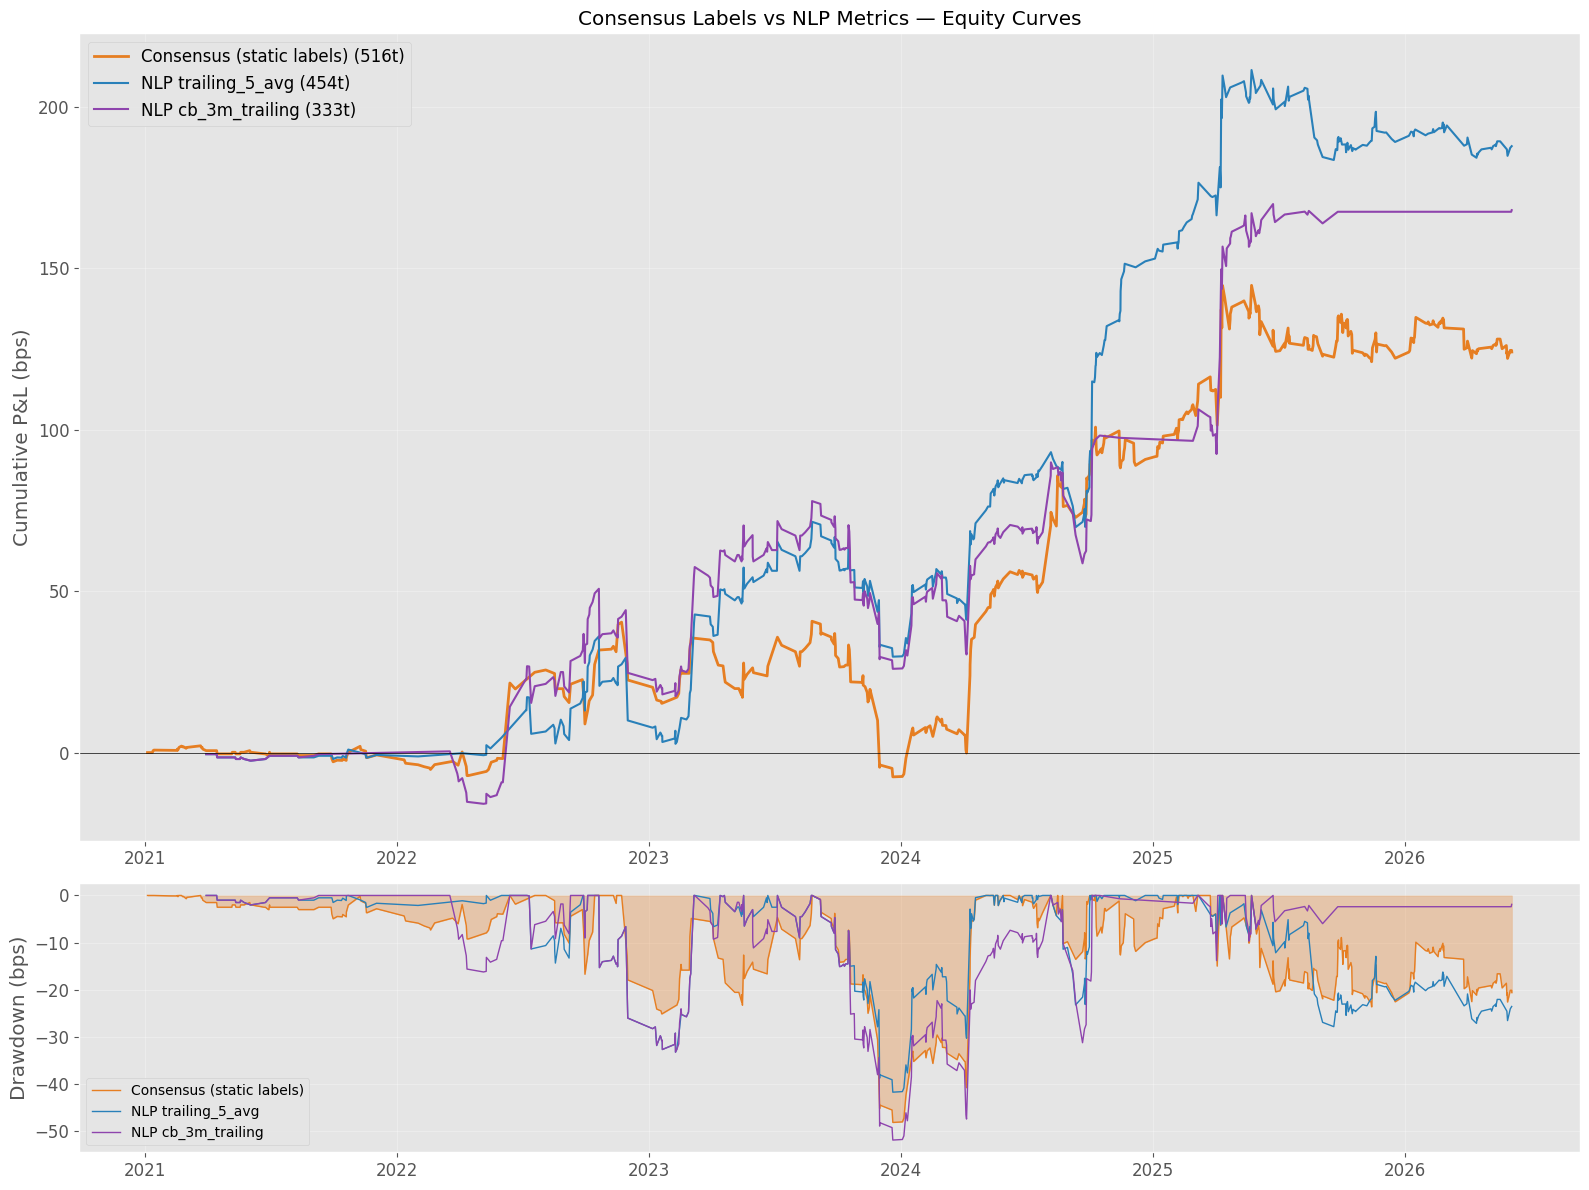

In [11]:
COLORS = {
    "consensus": "#e67e22",
    "trailing_5_avg": "#2980b9",
    "cb_3m_trailing_avg": "#8e44ad",
}
LABELS = {
    "consensus": "Consensus (static labels)",
    "trailing_5_avg": "NLP trailing_5_avg",
    "cb_3m_trailing_avg": "NLP cb_3m_trailing",
}

fig, axes = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={"height_ratios": [3, 1]})

# Equity curves
ax = axes[0]
ax.plot(closed["opened_at"].values, closed["cum_bps"].values,
        lw=2, color=COLORS["consensus"], label=f"{LABELS['consensus']} ({len(closed)}t)")
for metric in NLP_METRICS:
    cl = nlp_closed[metric]
    ax.plot(cl["opened_at"].values, cl["cum_bps"].values,
            lw=1.5, color=COLORS[metric], label=f"{LABELS[metric]} ({len(cl)}t)")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Cumulative P&L (bps)")
ax.set_title("Consensus Labels vs NLP Metrics — Equity Curves")
ax.legend(loc="upper left", fontsize=12)
ax.grid(True, alpha=0.3)

# Drawdown
ax2 = axes[1]
dd_c = closed["cum_bps"] - closed["cum_bps"].cummax()
ax2.fill_between(closed["opened_at"].values, dd_c.values, 0,
                 alpha=0.3, color=COLORS["consensus"])
ax2.plot(closed["opened_at"].values, dd_c.values,
         lw=1, color=COLORS["consensus"], label=LABELS["consensus"])
for metric in NLP_METRICS:
    cl = nlp_closed[metric]
    dd = cl["cum_bps"] - cl["cum_bps"].cummax()
    ax2.plot(cl["opened_at"].values, dd.values,
             lw=1, color=COLORS[metric], label=LABELS[metric])
ax2.set_ylabel("Drawdown (bps)")
ax2.legend(loc="lower left", fontsize=10)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Side-by-Side Summary

In [12]:
def calc_stats(cl, label):
    n = len(cl)
    yrs = max((cl["opened_at"].max() - cl["opened_at"].min()).days / 365.25, 0.5)
    tpy = n / yrs
    std = cl["pnl_bps"].std()
    avg = cl["pnl_bps"].mean()
    sr = (avg / std * np.sqrt(tpy)) if std > 0 else 0
    dd = (cl["cum_bps"] - cl["cum_bps"].cummax()).min()
    hawk = cl["direction"] == 1
    return {
        "Method": label, "Trades": n,
        "Hawk / Dove": f"{hawk.sum()} / {(~hawk).sum()}",
        "Cum bps": cl["pnl_bps"].sum(),
        "Avg bps": avg, "Hit Rate": cl["profitable"].mean(),
        "Sharpe": sr, "Max DD": dd,
        "Hawk bps": cl.loc[hawk, "pnl_bps"].sum(),
        "Dove bps": cl.loc[~hawk, "pnl_bps"].sum(),
    }

rows = [calc_stats(closed, "Consensus (static)")]
for metric in NLP_METRICS:
    rows.append(calc_stats(nlp_closed[metric], f"NLP {metric}"))

cmp_df = pd.DataFrame(rows)
display(cmp_df.style.format({
    "Cum bps": "{:+.1f}", "Avg bps": "{:+.3f}",
    "Hit Rate": "{:.1%}", "Sharpe": "{:.2f}",
    "Max DD": "{:.1f}", "Hawk bps": "{:+.1f}", "Dove bps": "{:+.1f}",
}).background_gradient(subset=["Sharpe"], cmap="RdYlGn"))

# Year-level comparison
print("\nCalendar-Year Total bps:")
all_years = sorted(set(closed["year"].unique()))
yr_cmp = {"Consensus": {}, **{m: {} for m in NLP_METRICS}}
for yr in all_years:
    yr_cmp["Consensus"][yr] = closed[closed["year"] == yr]["pnl_bps"].sum()
    for m in NLP_METRICS:
        sub = nlp_closed[m]
        yr_cmp[m][yr] = sub[sub["year"] == yr]["pnl_bps"].sum() if yr in sub["year"].values else 0

yr_df = pd.DataFrame(yr_cmp, index=all_years).T
display(yr_df.style.format("{:+.1f}").background_gradient(cmap="RdYlGn", axis=None))

,Method,Trades,Hawk / Dove,Cum bps,Avg bps,Hit Rate,Sharpe,Max DD,Hawk bps,Dove bps
0,Consensus (static),516,253 / 263,+124.0,+0.240,52.9%,0.67,-48.2,+109.7,+14.3
1,NLP trailing_5_avg,454,380 / 74,+187.8,+0.414,57.5%,1.01,-41.8,+197.3,-9.5
2,NLP cb_3m_trailing_avg,333,310 / 23,+168.0,+0.504,56.2%,0.86,-51.9,+168.5,-0.5



Calendar-Year Total bps:


,2021,2022,2023,2024,2025,2026
Consensus,-0.7,+23.2,-30.0,+98.3,+31.3,+1.9
trailing_5_avg,-0.7,+10.7,+19.7,+122.4,+37.0,-1.3
cb_3m_trailing_avg,-0.5,+25.2,+1.2,+71.5,+70.0,+0.5
